Following the previous analysis, I visualize all ISs.
The figure was used to infer the path of evolution of the ISs manually.

In [1]:
library(tidyverse)
library(cowplot)
library(latex2exp)
library(gggenes)
library(IRkernel)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
run_id <- "multiple_runs14"
input_dir <- file.path("exp", run_id, "data", "is_variants_analysis")
figure_export_dir = file.path(input_dir, "figures", "full")

In [3]:
annotations <- read_tsv(file.path(input_dir, "annotation_of_variants.blastn"), comment = '#',
col_names = c("sseqid", "qseqid", "qstart", "qend", "sstart", "send", "length", "evalue", "bitscore", "pident")) %>%
filter(qseqid != "Full_IS1" | length > 3000)  
reordered_levels <- annotations %>%
  group_by(sseqid) %>%
  summarise(max_s= max(sstart, send)) %>%
  arrange(desc(max_s)) %>%
  pull(sseqid)
annotations$sseqid <- factor(annotations$sseqid, levels = reordered_levels)
annotations <- annotations %>% 
	separate_wider_delim(sseqid, delim = ".", names = c("Line", "Gen", "IS"), cols_remove = F)
head(annotations)

Rows: 25267 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): sseqid, qseqid
dbl (8): qstart, qend, sstart, send, length, evalue, bitscore, pident

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Line,Gen,IS,sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L10-2,3,19,L10-2.3.19,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100
L10-2,3,19,L10-2.3.19,IS1-IRL,1,23,696,718,23,5.17e-06,42.8,100
L10-2,2,20,L10-2.2.20,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100
L10-2,2,20,L10-2.2.20,IS1-IRL,1,23,695,717,23,5.17e-06,42.8,100
L02-2,2,22,L02-2.2.22,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100
L02-2,2,22,L02-2.2.22,IS1-IRL,1,23,650,672,23,5.17e-06,42.8,100


## set the directions for visualization

In [4]:
# check if the length is within - 10bp or 10% of the fragment size
# [23, 699, 624, 699, 23, 3092]
# ['IS1-IRL', 'IS1FS', 'TetR', 'mScarlet-I', 'IS1-IRR', 'Full_IS1']
# create a data frame with the lengths of each qseqid
qseqid_lengths <- data.frame(
  qseqid = c('IS1-IRL', 'IS1FS', 'TetR', 'mScarlet-I', 'IS1-IRR', 'Full_IS1'),
  length.full = c(23, 699, 624, 699, 23, 3092)
)

fragment_df <- annotations %>% filter(qseqid != "Full_IS1") %>% 
left_join(qseqid_lengths, by = "qseqid") %>%
mutate(match = ifelse(length>length.full, 1, length/length.full)) 
fragment_df %>% head

Line,Gen,IS,sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,length.full,match
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L10-2,3,19,L10-2.3.19,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L10-2,3,19,L10-2.3.19,IS1-IRL,1,23,696,718,23,5.17e-06,42.8,100,23,1
L10-2,2,20,L10-2.2.20,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L10-2,2,20,L10-2.2.20,IS1-IRL,1,23,695,717,23,5.17e-06,42.8,100,23,1
L02-2,2,22,L02-2.2.22,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L02-2,2,22,L02-2.2.22,IS1-IRL,1,23,650,672,23,5.17e-06,42.8,100,23,1


In [5]:
fragment_df %>% filter(sseqid == "L05-4.1.7")

Line,Gen,IS,sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,length.full,match
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L05-4,1,7,L05-4.1.7,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,1,7,L05-4.1.7,IS1FS,1,699,364,1062,699,0.00e+00,1261.0,100,699,1
L05-4,1,7,L05-4.1.7,TetR,1,624,1234,1857,624,0.00e+00,1126.0,100,624,1
L05-4,1,7,L05-4.1.7,mScarlet-I,1,699,2217,2915,699,0.00e+00,1261.0,100,699,1
L05-4,1,7,L05-4.1.7,IS1-IRR,1,23,3071,3093,23,5.17e-06,42.8,100,23,1


In [6]:
lengths <- read_csv(file.path(input_dir, "is_variant_lengths.csv"))
# reorder by length
lengths$id <- factor(lengths$id, levels = reorder(lengths$id, lengths$length))
#lengths <- lengths %>% separate(id, c("Line", "Gen", "IS"), "\.", remove = FALSE) 
lengths <- lengths %>% separate_wider_delim(id, delim = ".", names = c("Line", "Gen", "IS"), cols_remove = F)
lengths %>% head

Rows: 2385 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): id
dbl (1): length

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Line,Gen,IS,id,length
<chr>,<chr>,<chr>,<fct>,<dbl>
L03-3,2,19,L03-3.2.19,1877
L06-2,3,4,L06-2.3.4,1920
L02-2,3,10,L02-2.3.10,3067
L02-2,3,16,L02-2.3.16,3067
L02-2,2,11,L02-2.2.11,3068
L08-3,3,7,L08-3.3.7,3085


In [7]:
full_is1 <- annotations %>% filter(qseqid == "Full_IS1") %>%
group_by(sseqid) %>% mutate(color = row_number()) %>% ungroup() 
full_is1 %>% head

Line,Gen,IS,sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,color
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
L02-1,3,4,L02-1.3.4,Full_IS1,1,3092,1554,4645,3092,0,5577,100,1
L02-1,3,5,L02-1.3.5,Full_IS1,1,3092,3751,6842,3092,0,5577,100,1
L02-4,2,16,L02-4.2.16,Full_IS1,1,3092,1,3092,3092,0,5577,100,1
L01-2,2,15,L01-2.2.15,Full_IS1,1,3092,1572,4663,3092,0,5577,100,1
L01-3,3,16,L01-3.3.16,Full_IS1,1,3092,1571,4662,3092,0,5577,100,1
L01-2,3,8,L01-2.3.8,Full_IS1,1,3092,1571,4662,3092,0,5577,100,1


In [8]:
#full_is1 <- full_is1 %>% filter(length > 3090)
full_is1 %>% arrange((length)) %>% head

Line,Gen,IS,sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,color
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
L02-4,3,14,L02-4.3.14,Full_IS1,1,3089,1,3089,3089,0,5571,100.000,1
L04-3,3,26,L04-3.3.26,Full_IS1,1,3089,1,3090,3090,0,5565,99.968,1
L03-4,3,21,L03-4.3.21,Full_IS1,1,3090,1,3091,3091,0,5562,99.935,1
L02-2,3,11,L02-2.3.11,Full_IS1,1,3090,1,3089,3091,0,5551,99.903,1
L02-1,3,4,L02-1.3.4,Full_IS1,1,3092,1554,4645,3092,0,5577,100.000,1
L02-1,3,5,L02-1.3.5,Full_IS1,1,3092,3751,6842,3092,0,5577,100.000,1


In [9]:
annotations %>% group_by(Line) %>% summarise(n = sum(qseqid == "Full_IS1"))

Line,n
<chr>,<int>
L01-1,57
L01-2,47
L01-3,54
L01-4,53
L02-1,70
L02-2,71
L02-3,68
L02-4,76
L03-1,41


In [10]:
library(RColorBrewer)
cols_ <- c(RColorBrewer::brewer.pal(5, "Set2")[c(3,1)], "#be1521")
labs_ <- expression(italic("tpn"), italic("tetR"), italic("rfp"))

p <- ggplot() +
  geom_segment(
    data = lengths %>% filter(Line == "L10-2"), 
    aes(x = 0, xend = length, y = id, yend = id), 
    size = 0.5, color = "grey"
  ) +
  geom_linerange(
    data = full_is1 %>% filter(Line == "L10-2"),
    aes(xmin = sstart, xmax = send, y = sseqid, linetype = as.factor(color)), 
    size = .6,
    position = position_nudge(y = 0.4)
  ) +
  scale_linetype_discrete(guide = "none") +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == "L10-2") %>%
      filter(!qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
      mutate(qseqid = case_when(
        qseqid == "IS1FS" ~ "tpn",
        qseqid == "TetR" ~ "tetR",
        qseqid == "mScarlet-I" ~ "rfp",
        TRUE ~ qseqid
      )) %>%
      mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
    aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match == 1),
    size = 0.1,
    arrowhead_width = unit(2.5, "mm"),
    arrowhead_height = unit(2.0, "mm"),
    arrow_body_height = unit(1.0, "mm")
  ) +
  scale_alpha_discrete(guide = "none", range = c(0.5, 1), name = "") +
  scale_fill_manual(values = cols_, labels = labs_, name = "") +
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA)) +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == "L10-2") %>%
      filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
    aes(xmin = sstart, xmax = send, y = sseqid), 
    fill = "grey",
    arrowhead_width = unit(0.5, "mm"),
    arrowhead_height = unit(1.5, "mm"),
    arrow_body_height = unit(0.1, "mm"),
    size = .3
  ) +
  facet_grid(Gen~., scales = "free_y", space = "free_y") +
  theme_minimal_vgrid(10) +
  theme(
    panel.grid.minor = element_blank(), 
    axis.text.y = element_text(hjust = 0, size = 6),
    axis.ticks.y = element_blank(), 
    axis.line.y = element_blank(),
    strip.background = element_blank(),
    strip.text.y = element_blank(), #element_text(angle = 0, size = 10),
    legend.position = "none", #c(1, 0.5), 
    legend.justification = c(1, 0.5),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene")

ggsave(file.path(figure_export_dir, "is_variants_L10-2.png"), p, width = 120, height = 110, units = "mm", dpi = 1000)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Using alpha for a discrete variable is not advised.”


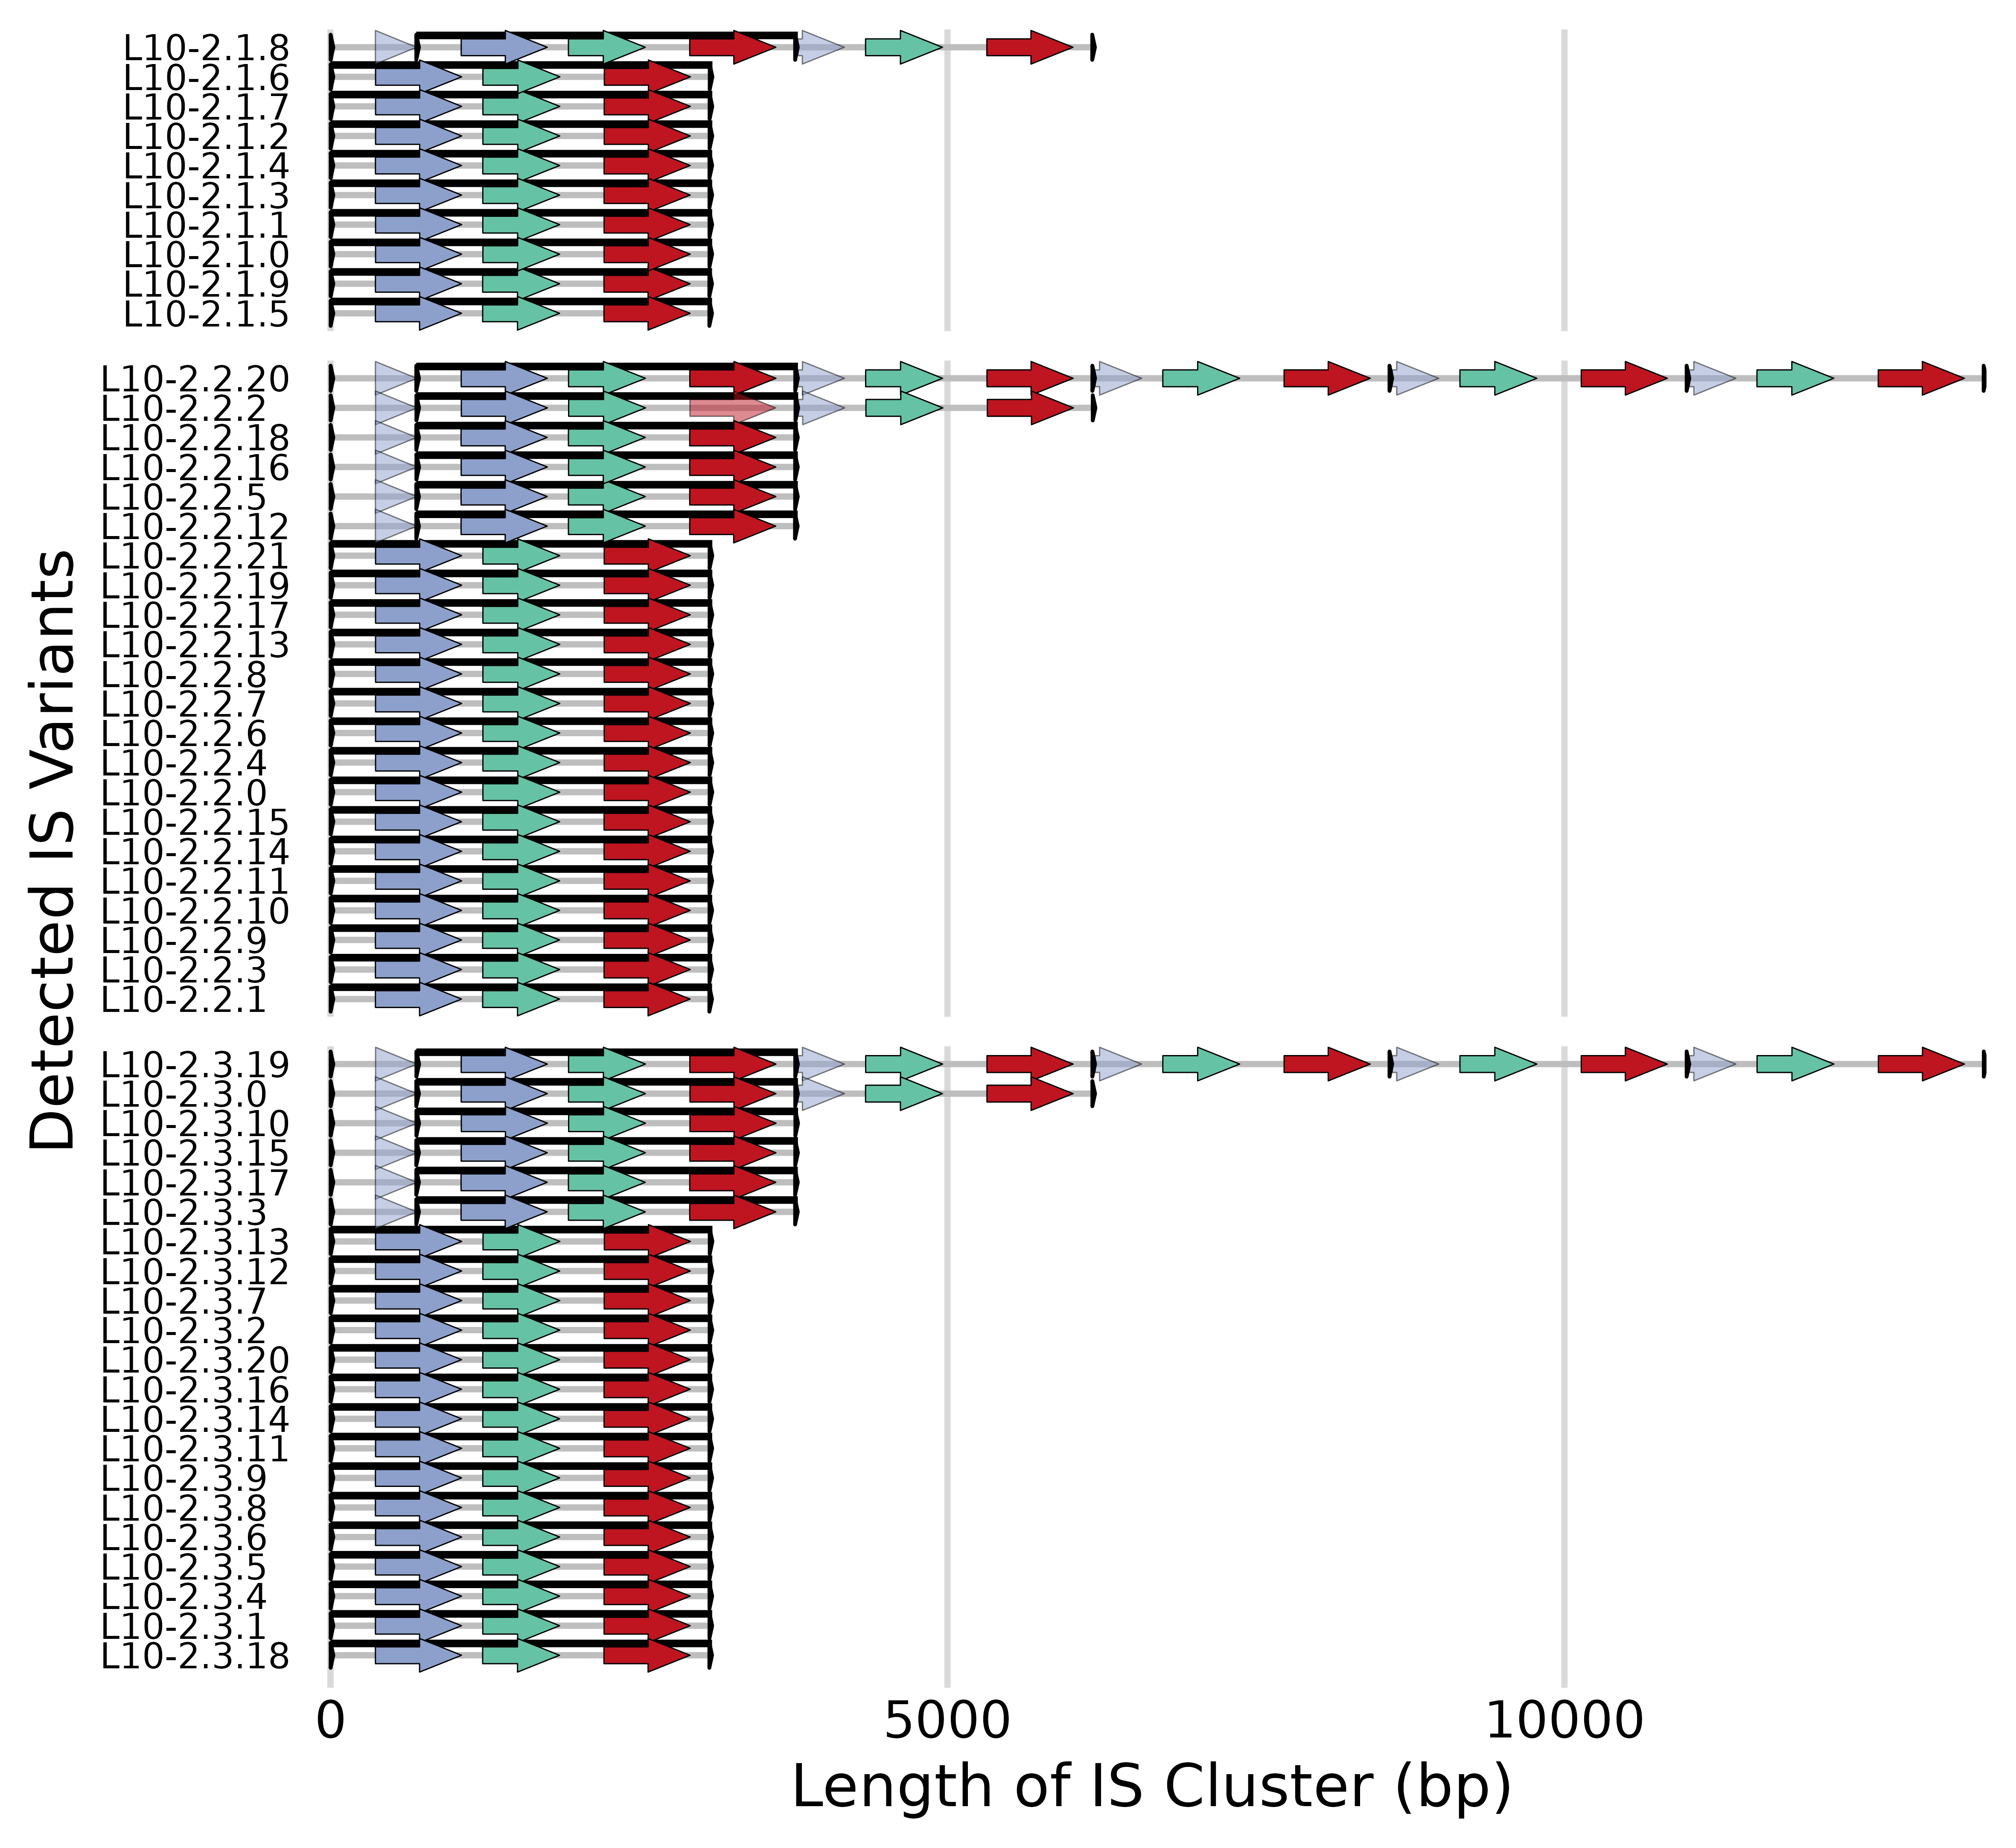

In [11]:
IRdisplay::display_png(file=file.path(figure_export_dir, "is_variants_L10-2.png"))

In [12]:
fragment_df %>% filter(Line == "L05-4")

Line,Gen,IS,sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,length.full,match
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L05-4,2,15,L05-4.2.15,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,2,17,L05-4.2.17,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,2,16,L05-4.2.16,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,3,29,L05-4.3.29,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,3,28,L05-4.3.28,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,3,27,L05-4.3.27,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,3,24,L05-4.3.24,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,3,20,L05-4.3.20,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L05-4,3,19,L05-4.3.19,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1


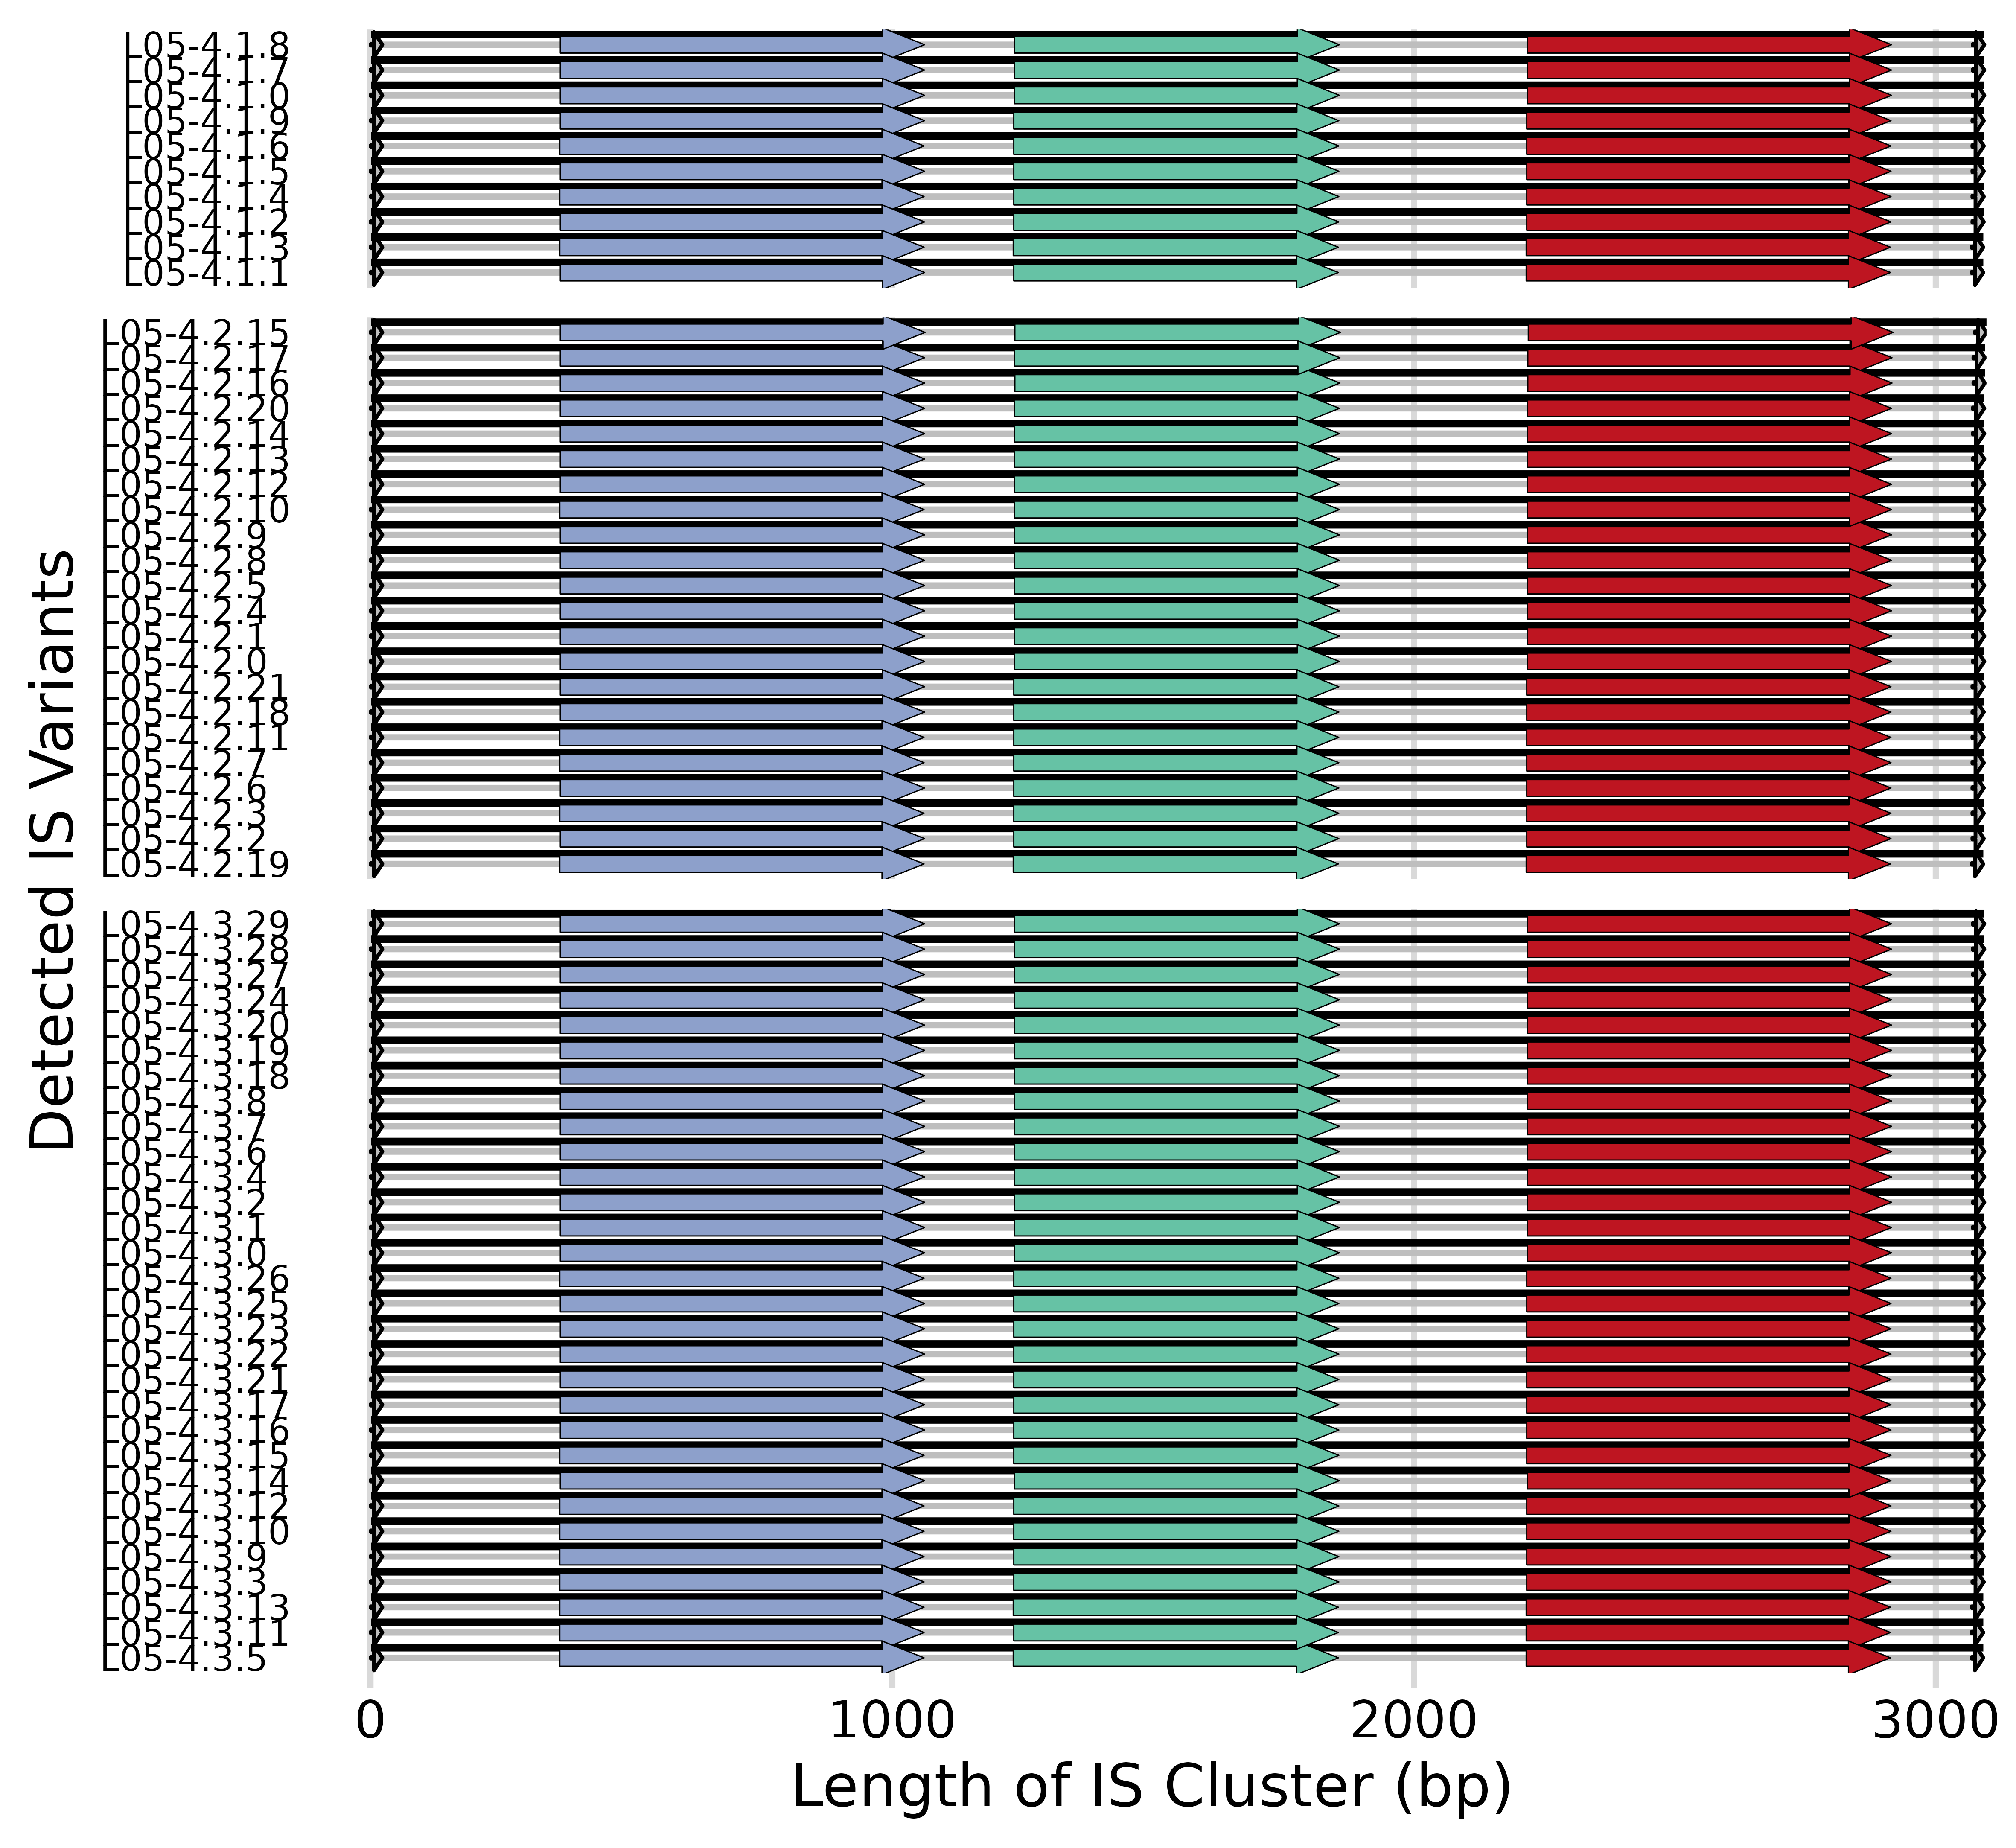

In [13]:
library(RColorBrewer)
cols_ <- c(RColorBrewer::brewer.pal(5, "Set2")[c(3,1)], "#be1521")
labs_ <- expression(italic("tpn"), italic("tetR"), italic("rfp"))

p <- ggplot() +
  geom_segment(
    data = lengths %>% filter(Line == "L05-4"), 
    aes(x = 0, xend = length, y = id, yend = id), 
    size = 0.5, color = "grey"
  ) +
  geom_linerange(
    data = full_is1 %>% filter(Line == "L05-4"),
    aes(xmin = sstart, xmax = send, y = sseqid, linetype = as.factor(color)), 
    size = .6,
    position = position_nudge(y = 0.4)
  ) +
  scale_linetype_discrete(guide = "none") +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == "L05-4") %>%
      filter(!qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
      mutate(qseqid = case_when(
        qseqid == "IS1FS" ~ "tpn",
        qseqid == "TetR" ~ "tetR",
        qseqid == "mScarlet-I" ~ "rfp",
        TRUE ~ qseqid
      )) %>%
      mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
    aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match == 1),
    size = 0.1,
    arrowhead_width = unit(2.5, "mm"),
    arrowhead_height = unit(2.0, "mm"),
    arrow_body_height = unit(1.0, "mm")
  ) +
  #scale_alpha_discrete(guide = "none", range = c(0.5, 1), name = "") +
  scale_alpha_manual(values = c("TRUE" = 1, "FALSE" = 0.5), guide = "none", name = "") +
  scale_fill_manual(values = cols_, labels = labs_, name = "") +
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA)) +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == "L05-4") %>%
      filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
    aes(xmin = sstart, xmax = send, y = sseqid), 
    fill = "grey",
    arrowhead_width = unit(0.5, "mm"),
    arrowhead_height = unit(1.5, "mm"),
    arrow_body_height = unit(0.1, "mm"),
    size = .3
  ) +
  facet_grid(Gen~., scales = "free_y", space = "free_y") +
  theme_minimal_vgrid(10) +
  theme(
    panel.grid.minor = element_blank(), 
    axis.text.y = element_text(hjust = 0, size = 6),
    axis.ticks.y = element_blank(), 
    axis.line.y = element_blank(),
    strip.background = element_blank(),
    strip.text.y = element_blank(), #element_text(angle = 0, size = 10),
    legend.position = "none", #c(1, 0.5), 
    legend.justification = c(1, 0.5),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene")

ggsave(file.path(figure_export_dir, "is_variants_L05-4.png"), p, width = 120, height = 110, units = "mm", dpi = 1000)
IRdisplay::display_png(file=file.path(figure_export_dir, "is_variants_L05-4.png"))

In [14]:
# Define your colors and labels
cols_ <- c(RColorBrewer::brewer.pal(5, "Set2")[c(3,1)], "#be1521")
labs_ <- expression(italic("tpn"), italic("tetR"), italic("rfp"))

# Get unique values from the Line column
line_values <- unique(lengths$Line)

# Loop through each line and create a plot
for (line in line_values) {
  p <- ggplot() +
  geom_segment(
    data = lengths %>% filter(Line == line), 
    aes(x = 0, xend = length, y = id, yend = id), 
    size = 0.5, color = "grey"
  ) +
  geom_linerange(
    data = full_is1 %>% filter(Line == line),
    aes(xmin = sstart, xmax = send, y = sseqid, linetype = as.factor(color)), 
    size = .6,
    position = position_nudge(y = 0.4)
  ) +
  scale_linetype_discrete(guide = "none") +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == line) %>%
      filter(!qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
      mutate(qseqid = case_when(
        qseqid == "IS1FS" ~ "tpn",
        qseqid == "TetR" ~ "tetR",
        qseqid == "mScarlet-I" ~ "rfp",
        TRUE ~ qseqid
      )) %>%
      mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
    aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match == 1),
    size = 0.1,
    arrowhead_width = unit(2.5, "mm"),
    arrowhead_height = unit(2.0, "mm"),
    arrow_body_height = unit(1.0, "mm")
  ) +
  #scale_alpha_discrete(guide = "none", range = c(0.5, 1), name = "") +
  scale_alpha_manual(values = c("TRUE" = 1, "FALSE" = 0.5), guide = "none", name = "") +
  scale_fill_manual(values = cols_, labels = labs_, name ="") +
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA)) +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == line) %>%
      filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
    aes(xmin = sstart, xmax = send, y = sseqid), 
    fill = "grey",
    arrowhead_width = unit(0.5, "mm"),
    arrowhead_height = unit(1.5, "mm"),
    arrow_body_height = unit(0.1, "mm"),
    size = .3
  ) +
  facet_grid(Gen~., scales = "free_y", space = "free_y") +
  theme_minimal_vgrid(10) +
  theme(
    panel.grid.minor = element_blank(), 
    axis.text.y = element_text(hjust = 0, size = 6),
    axis.ticks.y = element_blank(), 
    axis.line.y = element_blank(),
    strip.background = element_blank(),
    strip.text.y = element_blank(), #element_text(angle = 0, size = 10),
    legend.position = "none", #c(1, 0.5), 
    legend.justification = c(1, 0.5),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene")

  # Save the plot to a file named based on the line
  file_name <- paste("is_variants_", line, ".png", sep = "")
  ggsave(file.path(figure_export_dir, "each_files", file_name), p, width = 120, height = 160, units = "mm", dpi = 1000)
  ggsave(file.path(figure_export_dir, "each_files", paste("is_variants_", line, ".pdf", sep = "")), p, width = 120, height = 160, units = "mm", dpi = 1000)
}

In [15]:
# combine PDFs
C = 'pdfunite '
for (line in line_values %>% sort) {
  C = paste(C, file.path(figure_export_dir, "each_files", paste("is_variants_", line, ".pdf", sep = "")))
}
C = paste(C, file.path(figure_export_dir, "is_variants_all.pdf"))
print(C)
system(C)

[1] "pdfunite  exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L01-1.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L01-2.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L01-3.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L01-4.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L02-1.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L02-2.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L02-3.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L02-4.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L03-1.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_files/is_variants_L03-2.pdf exp/multiple_runs14/data/is_variants_analysis/figures/full/each_f

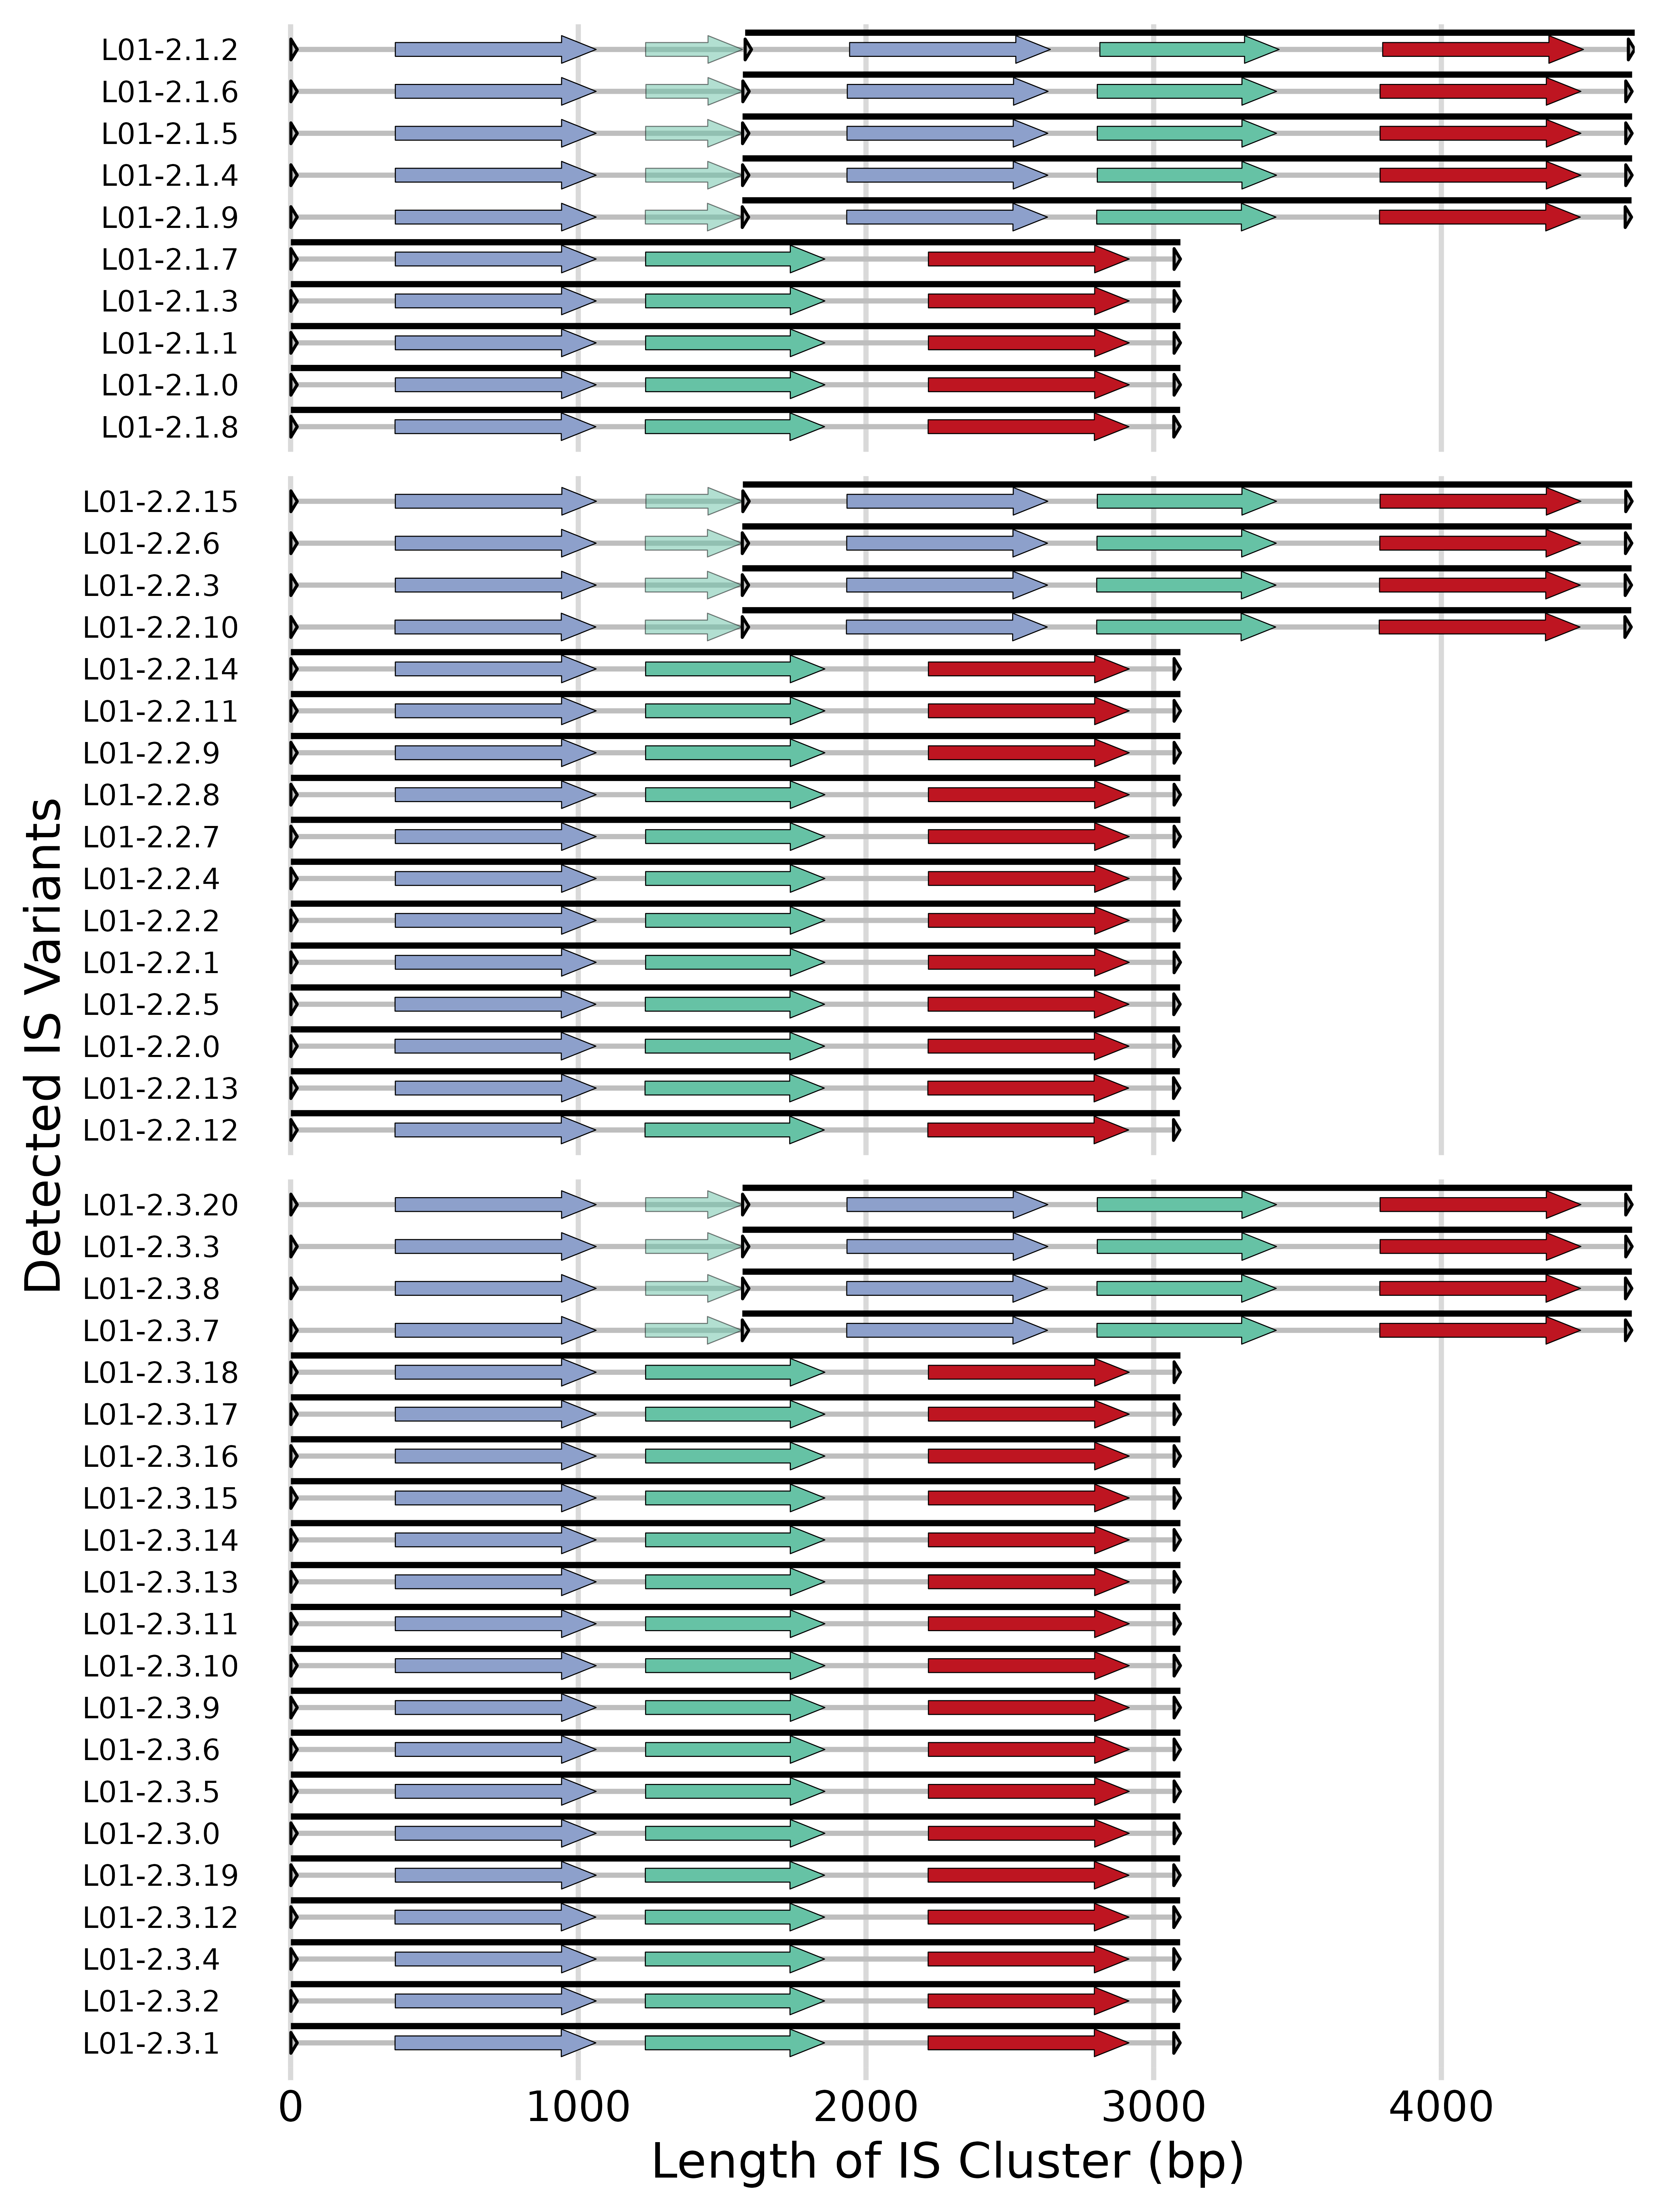

In [16]:
IRdisplay::display_png(file=file.path(figure_export_dir, "each_files", "is_variants_L01-2.png"))

## Plot for drawing schematic figure
This figure was c&p to create the schematic figure of IS evolution in line L10-3

Warning message:
“Using alpha for a discrete variable is not advised.”


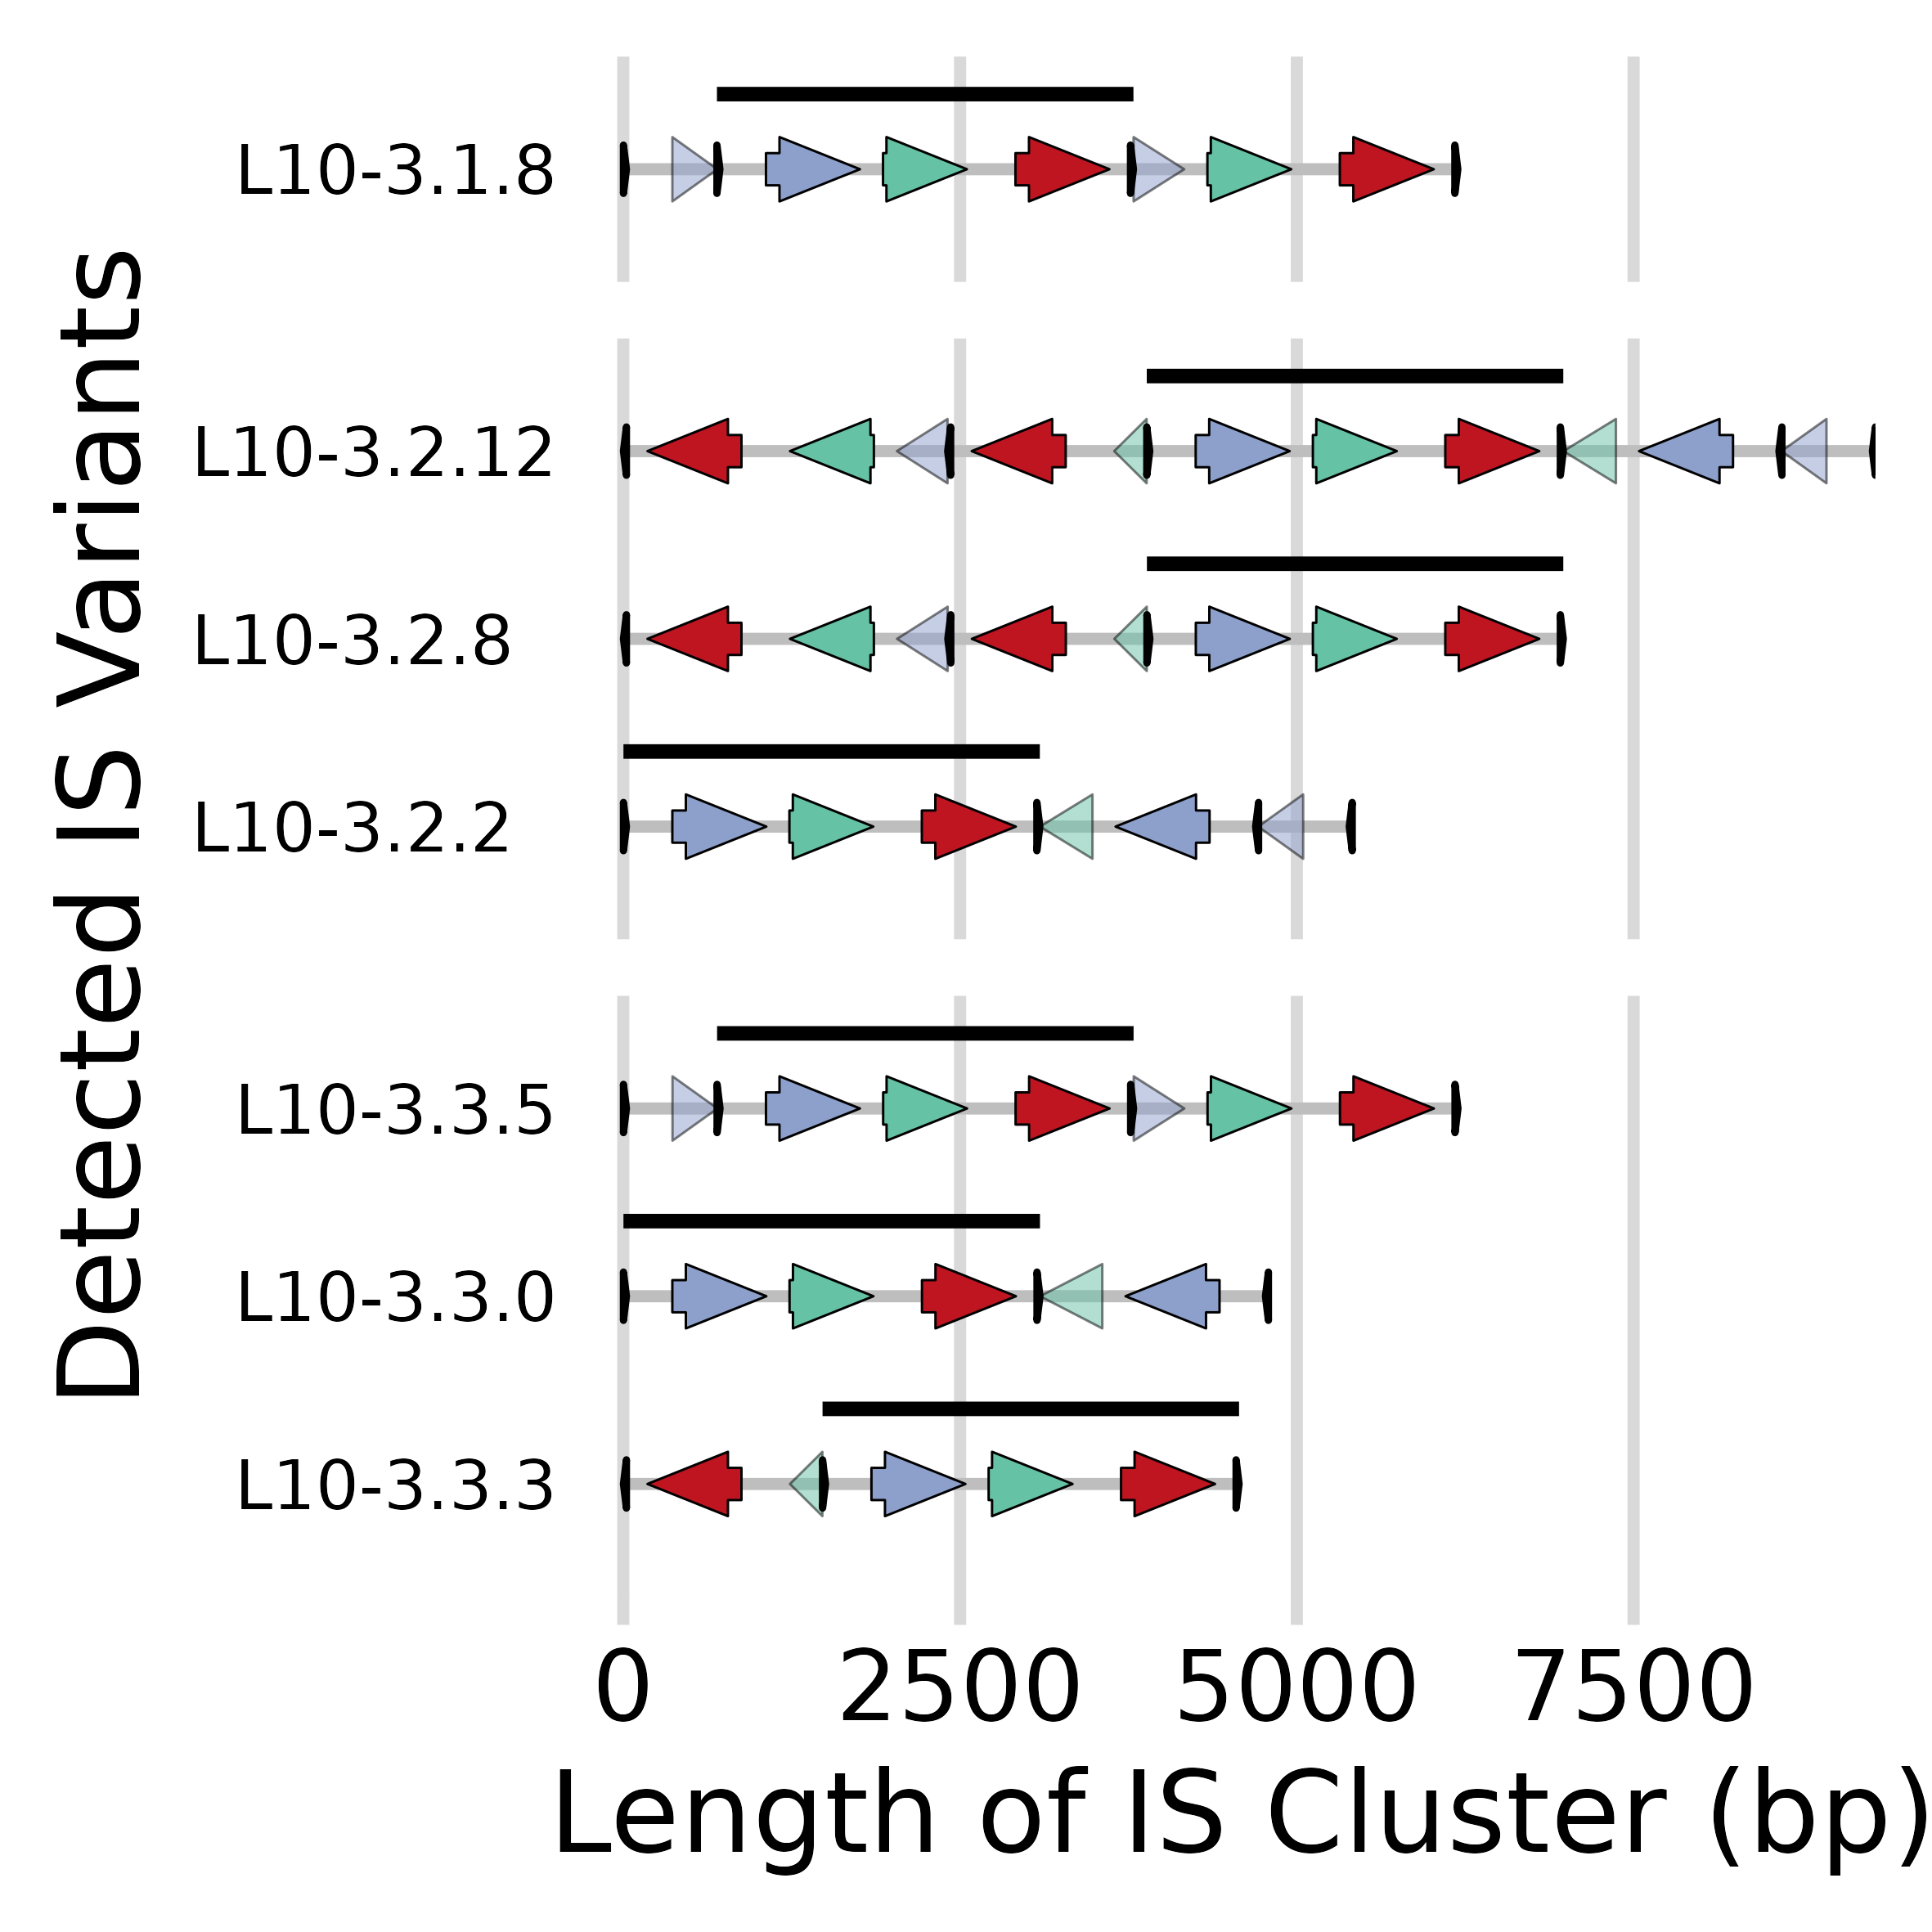

In [17]:
variants_to_display <- c(as.character(c(1.8, 2.12, 2.8, 2.2, 3.5, 3.3)), '3.0')
line <- "L10-3"

p <- ggplot() +
  geom_segment(
    data = lengths %>% filter(Line == line, paste0(Gen,".",IS) %in% variants_to_display), 
    aes(x = 0, xend = length, y = id, yend = id), 
    size = 0.5, color = "grey"
  ) +
  geom_linerange(
    data = full_is1 %>% filter(Line == line, paste0(Gen,".",IS) %in% variants_to_display),
    aes(xmin = sstart, xmax = send, y = sseqid, linetype = as.factor(color)), 
    size = .6,
    position = position_nudge(y = 0.4)
  ) +
  scale_linetype_discrete(guide = "none") +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == line, paste0(Gen,".",IS) %in% variants_to_display) %>%
      filter(!qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
      mutate(qseqid = case_when(
        qseqid == "IS1FS" ~ "tpn",
        qseqid == "TetR" ~ "tetR",
        qseqid == "mScarlet-I" ~ "rfp",
        TRUE ~ qseqid
      )) %>%
      mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
    aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match == 1),
    size = 0.1,
    arrowhead_width = unit(2.5, "mm"),
    arrowhead_height = unit(2.0, "mm"),
    arrow_body_height = unit(1.0, "mm")
  ) +
  scale_alpha_discrete(guide = "none", range = c(0.5, 1), name = "") +
  scale_fill_manual(values = cols_, labels = labs_, name = "") +
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA)) +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(Line == line, paste0(Gen,".",IS) %in% variants_to_display) %>%
      filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
    aes(xmin = sstart, xmax = send, y = sseqid), 
    fill = "grey",
    arrowhead_width = unit(0.5, "mm"),
    arrowhead_height = unit(1.5, "mm"),
    arrow_body_height = unit(0.1, "mm"),
    size = .3
  ) +
  facet_grid(Gen~., scales = "free_y", space = "free_y") +
  theme_minimal_vgrid(10) +
  theme(
    panel.grid.minor = element_blank(), 
    axis.text.y = element_text(hjust = 0, size = 6),
    axis.ticks.y = element_blank(), 
    axis.line.y = element_blank(),
    strip.background = element_blank(),
    strip.text.y = element_blank(), #element_text(angle = 0, size = 10),
    legend.position = "none", #c(1, 0.5), 
    legend.justification = c(1, 0.5),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene")

dir.create(file.path(figure_export_dir, "evolution"), recursive = TRUE, showWarnings = FALSE)

# Save the plot to a file named based on the line
ggsave(file.path(figure_export_dir, "evolution", paste0("evolution_10.3", ".svg")), p, width = 60, height = 60, units = "mm", dpi = 1000)
ggsave(file.path(figure_export_dir, "evolution", paste0("evolution_10.3", ".png")), p, width = 60, height = 60, units = "mm", dpi = 1000)
ggsave(file.path(figure_export_dir, "evolution", paste0("evolution_10.3", ".pdf")), p, width = 60, height = 60, units = "mm", dpi = 1000)

IRdisplay::display_png(file=file.path(figure_export_dir, "evolution", "evolution_10.3.png"))

Warning message:
“Using alpha for a discrete variable is not advised.”


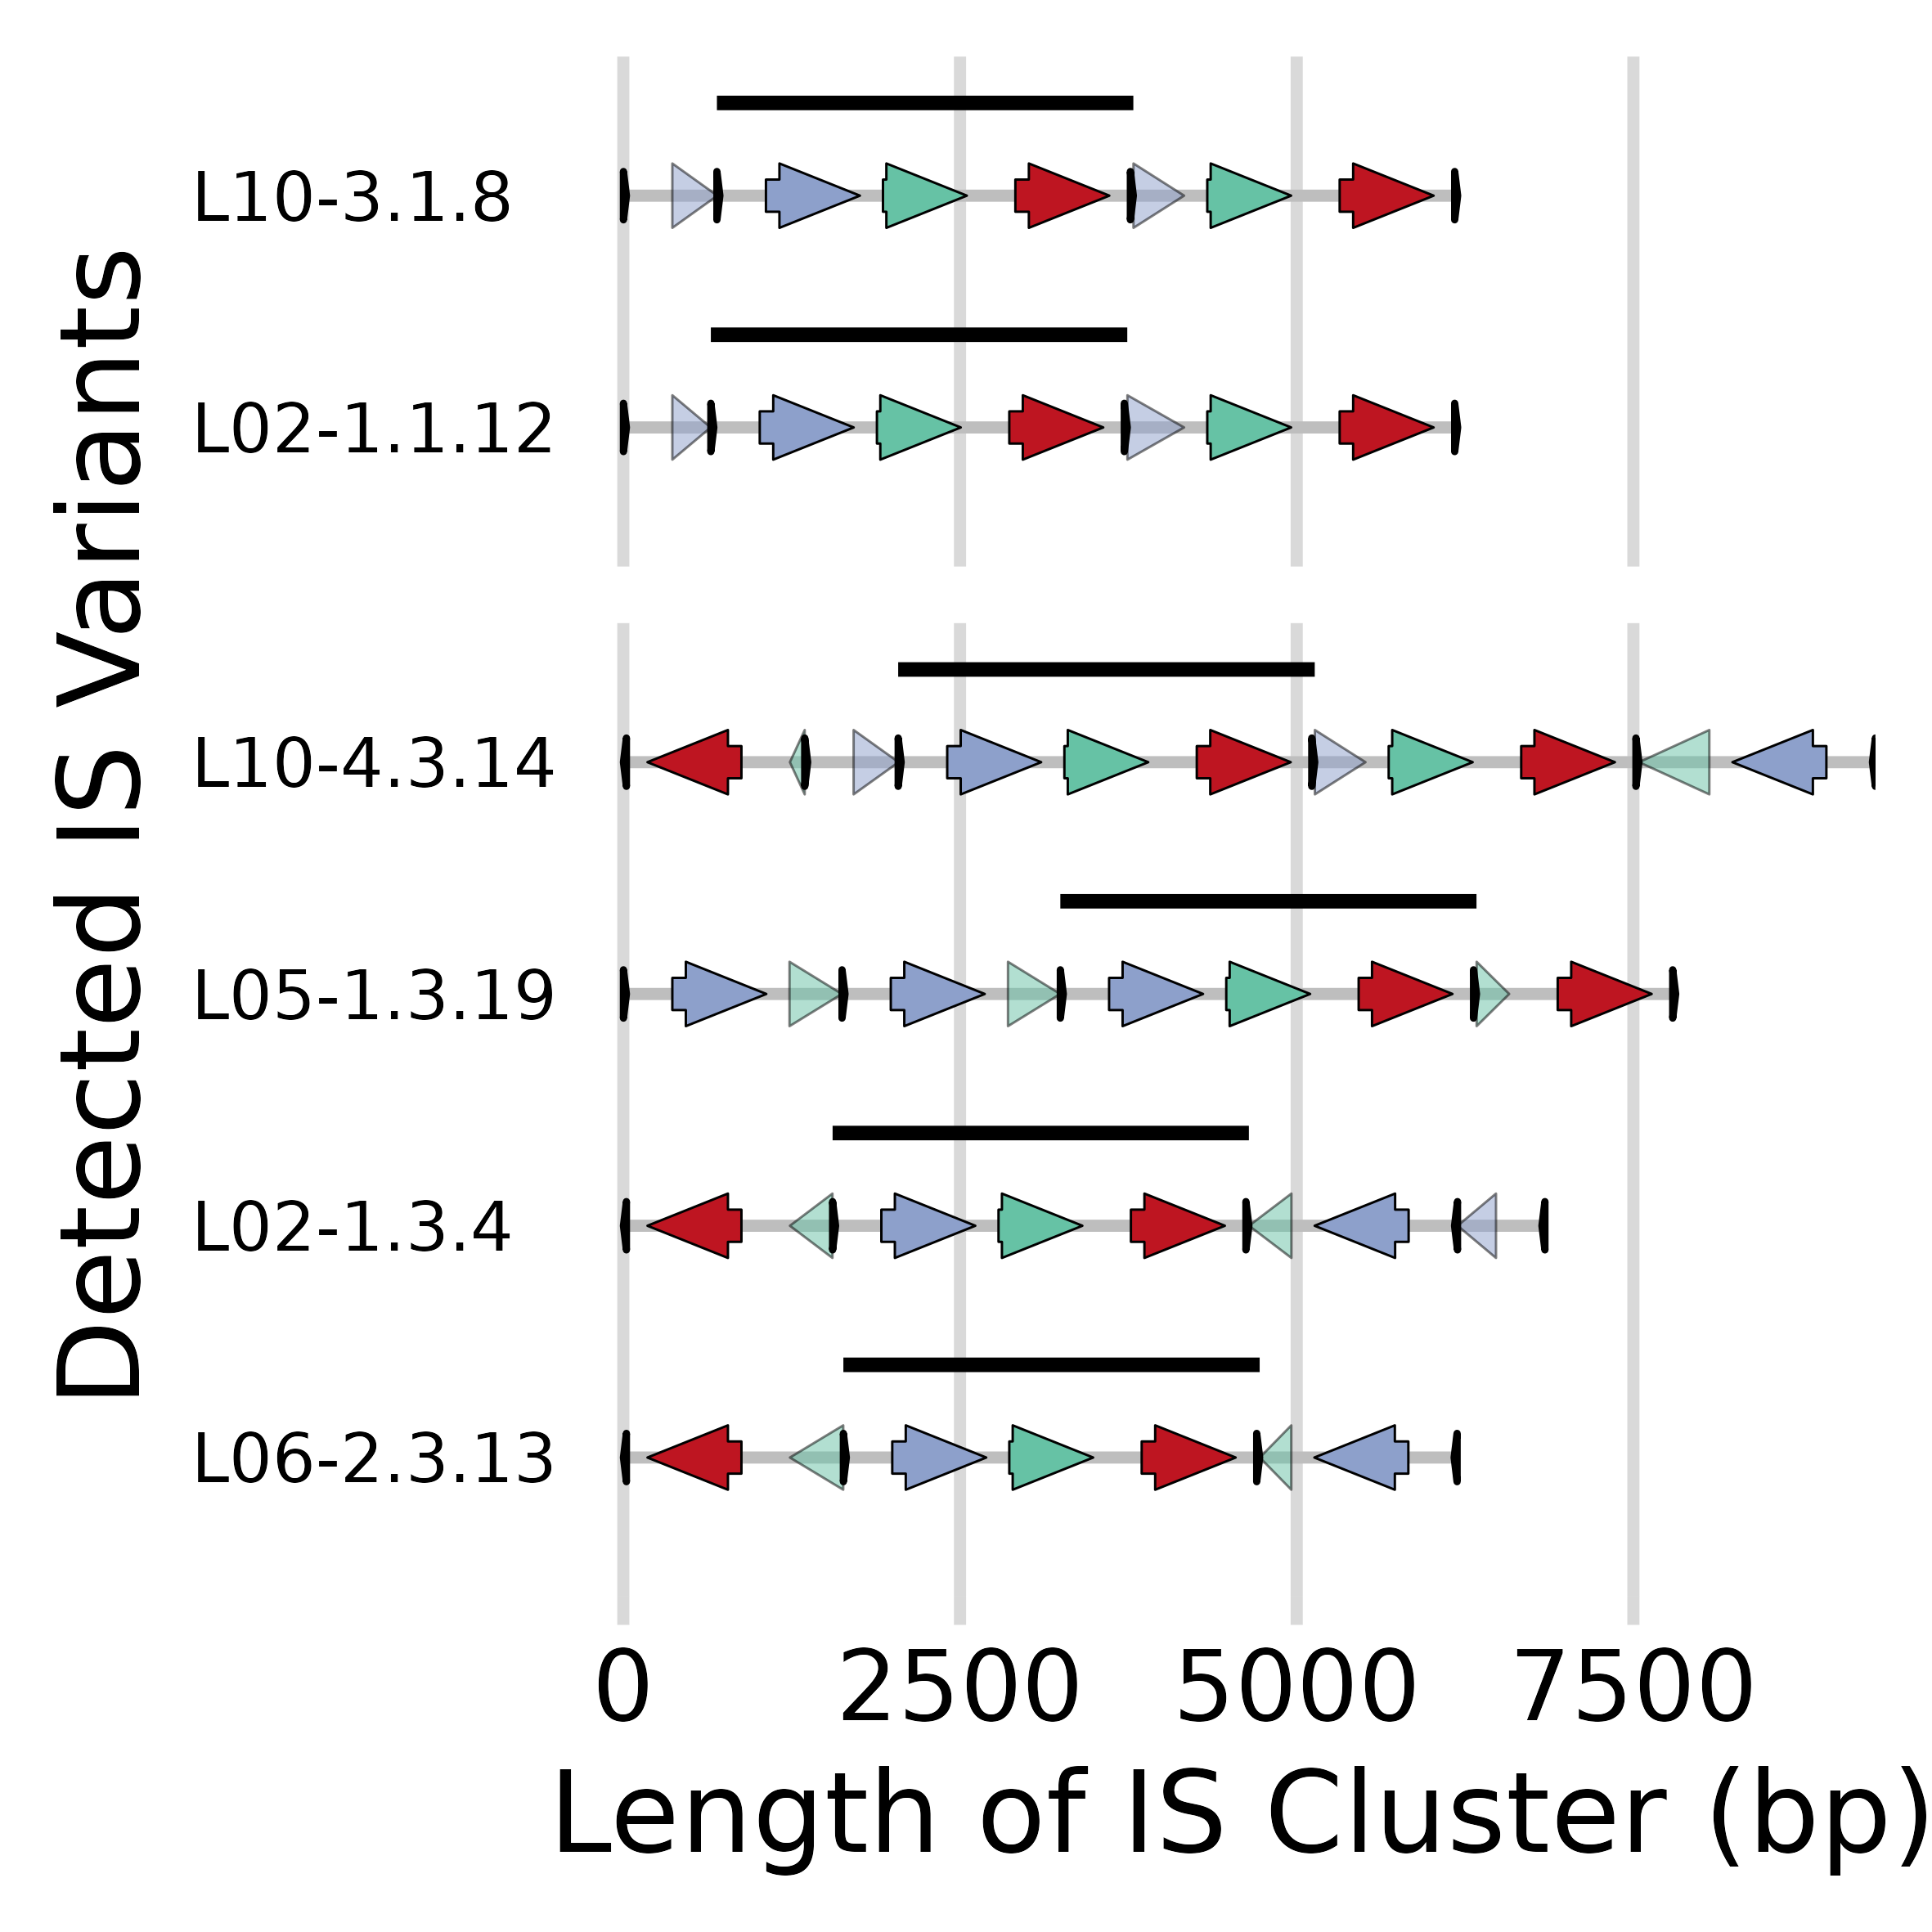

In [18]:
# example of IS in IS
variants_to_display <- c("L02-1.1.12", "L02-1.3.4", "L05-1.3.19", "L06-2.3.13", "L10-3.1.8",
  "L10-3.1.12", "L10-4.3.14")

p <- ggplot() +
  geom_segment(
    data = lengths %>% 
    filter(paste0(Line, ".", Gen,".",IS) %in% variants_to_display), 
    aes(x = 0, xend = length, y = id, yend = id), 
    size = 0.5, color = "grey"
  ) +
  geom_linerange(
    data = full_is1 %>%
    filter(paste0(Line, ".", Gen,".",IS) %in% variants_to_display), 
    aes(xmin = sstart, xmax = send, y = sseqid, linetype = as.factor(color)), 
    size = .6,
    position = position_nudge(y = 0.4)
  ) +
  scale_linetype_discrete(guide = "none") +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(paste0(Line, ".", Gen,".",IS) %in% variants_to_display) %>%
      filter(!qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
      mutate(qseqid = case_when(
        qseqid == "IS1FS" ~ "tpn",
        qseqid == "TetR" ~ "tetR",
        qseqid == "mScarlet-I" ~ "rfp",
        TRUE ~ qseqid
      )) %>%
      mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
    aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match == 1),
    size = 0.1,
    arrowhead_width = unit(2.5, "mm"),
    arrowhead_height = unit(2.0, "mm"),
    arrow_body_height = unit(1.0, "mm")
  ) +
  scale_alpha_discrete(guide = "none", range = c(0.5, 1), name = "") +
  scale_fill_manual(values = cols_, labels = labs_, name = "") +
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA)) +
  geom_gene_arrow(
    data = fragment_df %>% 
      filter(paste0(Line, ".", Gen,".",IS) %in% variants_to_display) %>%
      filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
    aes(xmin = sstart, xmax = send, y = sseqid), 
    fill = "grey",
    arrowhead_width = unit(0.5, "mm"),
    arrowhead_height = unit(1.5, "mm"),
    arrow_body_height = unit(0.1, "mm"),
    size = .3
  ) +
  facet_grid(Gen~., scales = "free_y", space = "free_y") +
  theme_minimal_vgrid(10) +
  theme(
    panel.grid.minor = element_blank(), 
    axis.text.y = element_text(hjust = 0, size = 6),
    axis.ticks.y = element_blank(), 
    axis.line.y = element_blank(),
    strip.background = element_blank(),
    strip.text.y = element_blank(), #element_text(angle = 0, size = 10),
    legend.position = "none", #c(1, 0.5), 
    legend.justification = c(1, 0.5),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene")

dir.create(file.path(figure_export_dir, "evolution"), recursive = TRUE, showWarnings = FALSE)

# Save the plot to a file named based on the line
ggsave(file.path(figure_export_dir, "evolution", paste0("evolution_nested", ".svg")), p, width = 60, height = 60, units = "mm", dpi = 1000)
ggsave(file.path(figure_export_dir, "evolution", paste0("evolution_nested", ".png")), p, width = 60, height = 60, units = "mm", dpi = 1000)
ggsave(file.path(figure_export_dir, "evolution", paste0("evolution_nested", ".pdf")), p, width = 60, height = 60, units = "mm", dpi = 1000)

IRdisplay::display_png(file=file.path(figure_export_dir, "evolution", "evolution_nested.png"))